<a href="https://colab.research.google.com/github/natsakh/ElectromagneticNets/blob/main/TimeVaryingMedia/Analytics/InitialValueProblems/02_time_jump_D_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abrupt Temporal Transition — Electric Displacement

## Problem formulation

We consider a plane electromagnetic wave propagating in a homogeneous, nondispersive medium. At \(t=0\), the refractive index changes instantaneously,

$$
n_1 \rightarrow n_2.
$$

The aim is to determine the temporal evolution of the electric displacement after the transition.

## Incident field

Before the temporal transition, the electric field is

$$
\mathbf{e}_0(z,t)
=
E_0 e^{i\omega_1 t}e^{-ik_1z}\,\mathbf{x},
$$

where

$$
k_1=\frac{n_1\omega_1}{c}.
$$

The corresponding electric displacement is

$$
\mathbf{d}_0(z,t)
=
\varepsilon_0 n_1^2 E_0
e^{i\omega_1t}e^{-ik_1z}\,\mathbf{x}.
$$

In this notebook, only the temporal dependence is considered. Equivalently, the field is evaluated at \(z=0\), and the common spatial factor $e^{-ik_1z}$ is omitted:

$$
d_0(t)
=
\varepsilon_0 n_1^2 E_0 e^{i\omega_1t}.
$$

## Wave equation after the time jump

For \(t>0\), the refractive index is constant and equal to \(n_2\). The electric displacement satisfies

$$
\frac{\partial^2\mathbf{d}(z,t)}{\partial z^2}
-
\frac{n_2^2}{c^2}
\frac{\partial^2\mathbf{d}(z,t)}{\partial t^2}
=
0.
$$

## Initial conditions

At a temporal interface, the electric displacement and its first time derivative are continuous.

Therefore,

$$
\mathbf{d}(z,+0)
=
\mathbf{d}_0(z,-0),
$$

and

$$
\left.
\frac{\partial\mathbf{d}(z,t)}{\partial t}
\right|_{t=+0}
=
\left.
\frac{\partial\mathbf{d}_0(z,t)}{\partial t}
\right|_{t=-0}.
$$

For the incident plane wave, these conditions become

$$
\mathbf{d}(z,+0)
=
\varepsilon_0 n_1^2E_0e^{-ik_1z}\,\mathbf{x},
$$

$$
\left.
\frac{\partial\mathbf{d}(z,t)}{\partial t}
\right|_{t=+0}
=
i\omega_1\varepsilon_0 n_1^2E_0e^{-ik_1z}\,\mathbf{x}.
$$

## Analytical solution

The spatial wavenumber is conserved at the temporal interface. Hence, the frequency after the transition is

$$
\omega_2=\frac{n_1}{n_2}\omega_1.
$$

For \(t>0\), the electric displacement is represented as a superposition of time-transmitted and time-reflected waves,

$$
d(t)
=
D_{\mathrm{T}}e^{i\omega_2t}
+
D_{\mathrm{R}}e^{-i\omega_2t}.
$$

The corresponding amplitudes are

$$
D_{\mathrm{T}}
=
\varepsilon_0E_0
\frac{n_1(n_1+n_2)}{2},
$$

$$
D_{\mathrm{R}}
=
\varepsilon_0E_0
\frac{n_1(n_1-n_2)}{2}.
$$

Thus, the final electric-displacement solution is

$$
d(t)
=
\varepsilon_0E_0\frac{n_1}{2}
\left[
(n_1+n_2)e^{i\omega_2t}
+
(n_1-n_2)e^{-i\omega_2t}
\right],
\qquad t>0.
$$

The electric displacement is related to the electric field after the transition by

$$
d(t)=\varepsilon_0n_2^2e(t).
$$

In [19]:
import numpy as np
import matplotlib.pyplot as plt

## Python implementation

In [20]:
def time_jump_D_analytics(t, n1, n2, w1, E0=1.0, eps0=1.0):

    w2 = n1 / n2 * w1

    D_T = eps0 * E0 * n1 * (n1 + n2) / 2
    D_R = eps0 * E0 * n1 * (n1 - n2) / 2

    d = (
        D_T * np.exp(1j * w2 * t)
        + D_R * np.exp(-1j * w2 * t)
    )

    return d, D_T, D_R

## Example

The reference period is defined by

$$
T_{\mathrm{ref}}=\frac{2\pi}{\omega_1}.
$$

Time is displayed in the normalized form
$t/T_{\mathrm{ref}}$. The electric displacement is normalized by $\varepsilon_0E_0$.

In [21]:
n1 = 1.5
n2 = 1.0
w1 = 2 * np.pi
E0 = 1.0
eps0 = 1.0

T_ref = 2 * np.pi / w1

t = np.linspace(-2 * T_ref, 5 * T_ref, 2000)

t_before = t[t < 0]
t_after = t[t >= 0]

d_incident = eps0 * n1**2 * E0 * np.exp(1j * w1 * t_before)

d_after, D_T, D_R = time_jump_D_analytics(
    t_after, n1, n2, w1, E0, eps0
)

w2 = n1 / n2 * w1

print(f"w2  = {w2:.6f}")
print(f"D_T = {D_T:.6f}")
print(f"D_R = {D_R:.6f}")

w2  = 9.424778
D_T = 1.875000
D_R = 0.375000


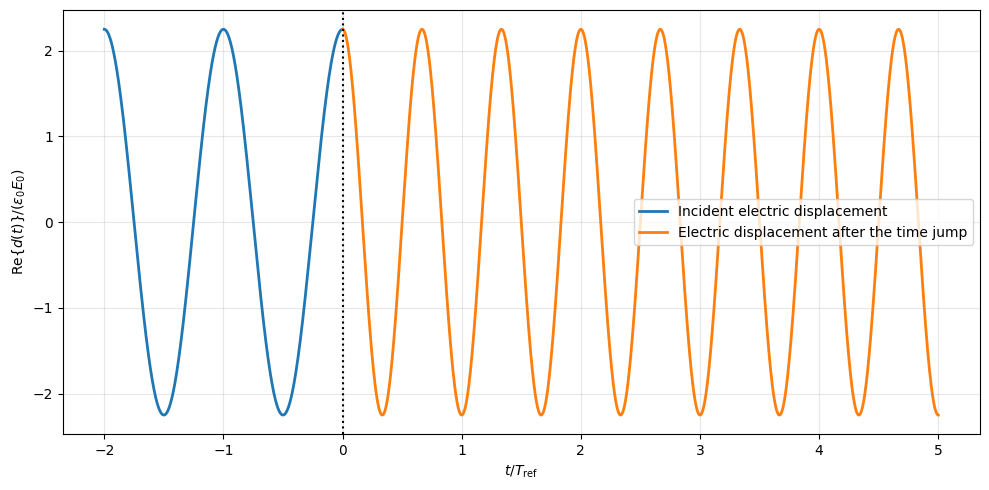

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    t_before / T_ref,
    np.real(d_incident) / (eps0 * E0),
    lw=2,
    label="Incident electric displacement"
)

plt.plot(
    t_after / T_ref,
    np.real(d_after) / (eps0 * E0),
    lw=2,
    label="Electric displacement after the time jump"
)

plt.axvline(0, color="black", ls=":", lw=1.5)

plt.xlabel(r"$t/T_{\mathrm{ref}}$")
plt.ylabel(r"$\mathrm{Re}\{d(t)\}/(\varepsilon_0E_0)$")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Magnetic induction

Once the electric displacement is known, the corresponding magnetic induction can be recovered from Faraday's law,

$$
\nabla\times\mathbf{e}(z,t)
=
-\frac{\partial\mathbf{b}(z,t)}{\partial t}.
$$

For \(t>0\),

$$
\mathbf{e}(z,t)
=
\frac{\mathbf{d}(z,t)}{\varepsilon_0n_2^2},
$$

and therefore

$$
\nabla\times\mathbf{d}(z,t)
=
-\varepsilon_0n_2^2
\frac{\partial\mathbf{b}(z,t)}{\partial t}.
$$

For the plane wave

$$
\mathbf{d}(z,t)
=
\left(
D_{\mathrm{T}}e^{i\omega_2t}
+
D_{\mathrm{R}}e^{-i\omega_2t}
\right)
e^{-ik_1z}\,\mathbf{x},
$$

the magnetic induction is

$$
\mathbf{b}(z,t)
=
\frac{1}{\varepsilon_0n_2c}
\left(
D_{\mathrm{T}}e^{i\omega_2t}
-
D_{\mathrm{R}}e^{-i\omega_2t}
\right)
e^{-ik_1z}\,\mathbf{y},
\qquad t>0.
$$

Substituting $D_{\mathrm{T}}$ and $D_{\mathrm{R}}$, we obtain

$$
\mathbf{b}(z,t)
=
\frac{E_0n_1}{2n_2c}
\left[
(n_1+n_2)e^{i\omega_2t}
-
(n_1-n_2)e^{-i\omega_2t}
\right]
e^{-ik_1z}\,\mathbf{y},
\qquad t>0.
$$

Before the temporal transition, the incident magnetic induction is

$$
\mathbf{b}_0(z,t)
=
\frac{n_1E_0}{c}
e^{i\omega_1t}
e^{-ik_1z}\,\mathbf{y}.
$$

As for the electric displacement, the common spatial factor is omitted in the numerical implementation below.


In [23]:
# The speed of light is set to one in the normalized numerical example
c = 1.0

b_incident = n1 * E0 / c * np.exp(1j * w1 * t_before)

b_after = (
    D_T * np.exp(1j * w2 * t_after)
    - D_R * np.exp(-1j * w2 * t_after)
) / (eps0 * n2 * c)


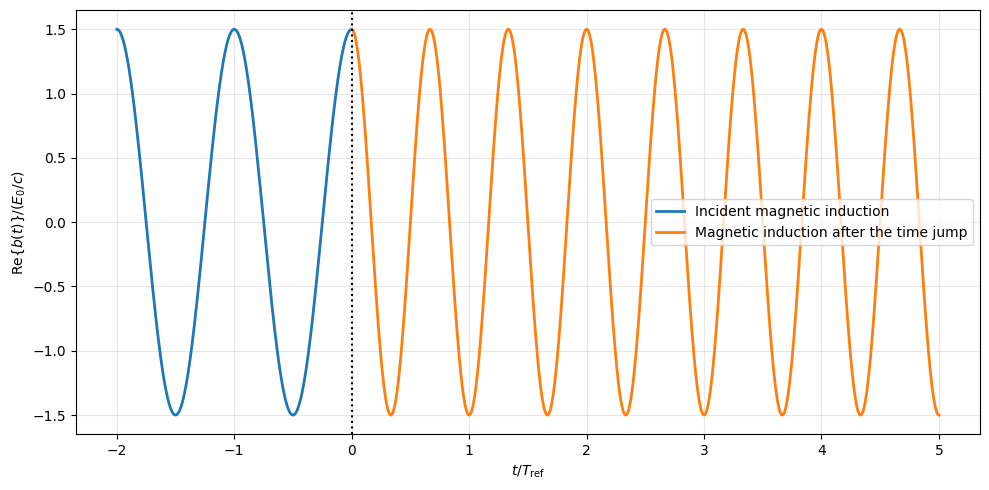

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    t_before / T_ref,
    np.real(b_incident) / (E0 / c),
    lw=2,
    label="Incident magnetic induction"
)

plt.plot(
    t_after / T_ref,
    np.real(b_after) / (E0 / c),
    lw=2,
    label="Magnetic induction after the time jump"
)

plt.axvline(0, color="black", ls=":", lw=1.5)

plt.xlabel(r"$t/T_{\mathrm{ref}}$")
plt.ylabel(r"$\mathrm{Re}\{b(t)\}/(E_0/c)$")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
